In [1]:
'''
1. Matplotlib
2. Seaborn
3. Plotly
----------------------
1. Bar Chart -> Column Chart, Clusterd Bar Chart, Stacked Bar Chart
2. Pie Chart -> Donut Chart
3. Line Chart
4. Correlation Heatmap
5. For Statistical Analysis -> Histogram, BoxPlot
6. Mostly used for machine learning -> Scatter Plot, Pair Plot
'''

'\n1. Matplotlib\n2. Seaborn\n3. Plotly\n----------------------\n1. Bar Chart -> Column Chart, Clusterd Bar Chart, Stacked Bar Chart\n2. Pie Chart -> Donut Chart\n3. Line Chart\n4. Correlation Heatmap\n5. For Statistical Analysis -> Histogram, BoxPlot\n6. Mostly used for machine learning -> Scatter Plot, Pair Plot\n'

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Line Plot

In [3]:
employees = ['Bob', 'John', 'Sadie', 'Abagil', 'Aurthr']
salary = [45000, 20000, 43000, 47000, 50000]
expense = [30000, 35000, 22025, 23000, 10000]

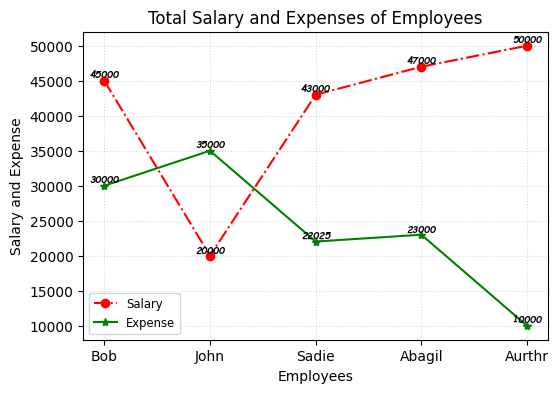

In [4]:
plt.figure(figsize=(6, 4)) # 600 x 400
# ax = plt.gca()  
# Setting Background colour yellow 
# ax.set_facecolor("green")
plt.plot(employees, salary, color='red', marker='o', linestyle='-.', label='Salary')
plt.plot(employees, expense, color='green', marker='*', label='Expense')
plt.xlabel('Employees')
plt.ylabel('Salary and Expense')
plt.title('Total Salary and Expenses of Employees')
plt.grid(linestyle='dotted', color='gray', alpha=0.3)
plt.legend(loc='best', fontsize='small')

for idx, val in enumerate(salary):
    plt.text(idx, val, str(val), ha='center', va='bottom',fontsize='x-small', fontstyle='italic', fontweight='bold',
            fontfamily='cursive')

for idx, val in enumerate(expense):
    plt.text(idx, val, str(val), ha='center', va='bottom',fontsize='x-small', fontstyle='italic', fontweight='bold',
            fontfamily='cursive')

plt.savefig('emp_salary.png')
plt.show()

## Bar Chart

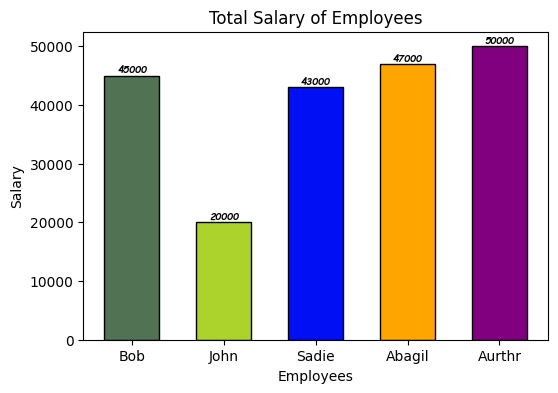

In [5]:
plt.figure(figsize=(6, 4))
colors = ['#517353', '#acd32b', '#000ff3', 'orange', 'purple']
plt.bar(employees, salary, color=colors, edgecolor='black', width=0.6)
plt.xlabel('Employees')
plt.ylabel('Salary')
plt.title('Total Salary of Employees')

for idx, val in enumerate(salary):
    plt.text(idx, val, str(val), ha='center', va='bottom',fontsize='x-small', fontstyle='italic', fontweight='bold',
            fontfamily='cursive')

plt.show()

<Axes: >

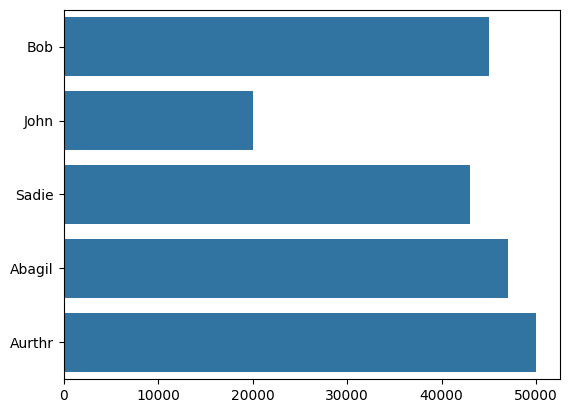

In [6]:
sns.barplot(x=salary, y=employees)

In [7]:
df = pd.read_csv('Dataset/temperature.csv')
df.head()

,Temperature (°C),Humidity (%)
0,23.745401,57.186649
1,29.507143,66.765614
2,27.319939,64.034868
3,25.986585,60.921443
4,21.560186,49.099373


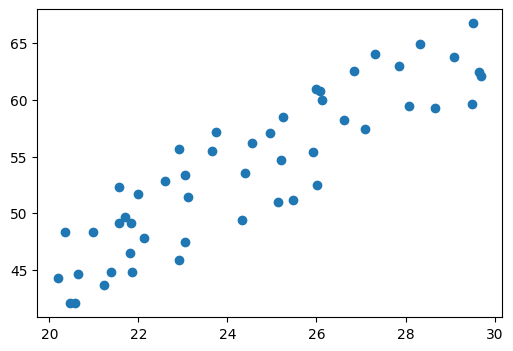

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Temperature (°C)'], df['Humidity (%)'])

## Histogram

In [12]:
hr = pd.read_csv('Dataset/cleaned_data1.csv')
hr.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Absences,HireYear,HireMonth,HireDay,HireMonthName,HireDayName,SalaryLabel,Salary_Num,Sal1,Sal2
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,1,2011,7,5,July,Tuesday,Low Salary,0,Low,Salary
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,17,2015,3,30,March,Monday,Average Salary,1,Average,Salary
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,3,2011,7,5,July,Tuesday,Low Salary,0,Low,Salary
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,15,2008,1,7,January,Monday,Low Salary,0,Low,Salary
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,2,2011,7,11,July,Monday,Low Salary,0,Low,Salary


In [13]:
hr['Salary'].skew()

np.float64(3.30618080924006)

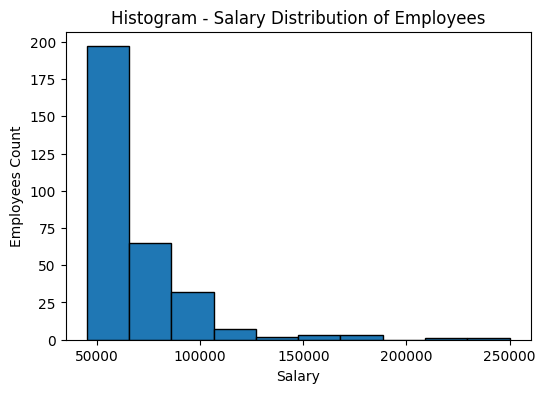

In [14]:
plt.figure(figsize=(6, 4))
plt.hist(hr['Salary'], edgecolor='black')
plt.xlabel('Salary')
plt.ylabel('Employees Count')
plt.title('Histogram - Salary Distribution of Employees')
plt.show()

In [15]:
sal_range = hr[hr['Salary'] < 70000]
sal_range['Salary'].skew()

np.float64(-0.32037102209607266)

In [16]:
mean_salary = sal_range['Salary'].mean()
median_salary = sal_range['Salary'].median()

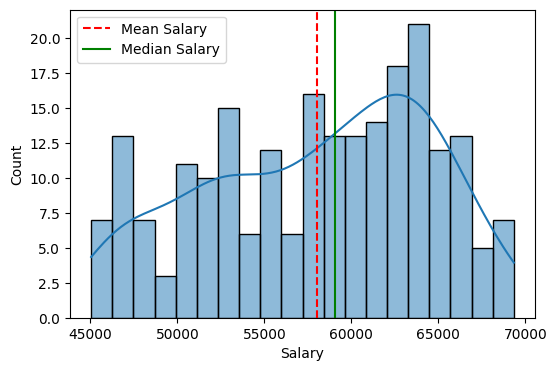

In [17]:
plt.figure(figsize=(6, 4))
# KDE -> Kernel Density Estimator
sns.histplot(sal_range['Salary'], bins=20, kde=True)
# axvline -> axis vertical line
plt.axvline(mean_salary, color='red', linestyle='dashed', label='Mean Salary')
plt.axvline(median_salary, color='green', label='Median Salary')
plt.legend()
plt.show()

## Box Plot

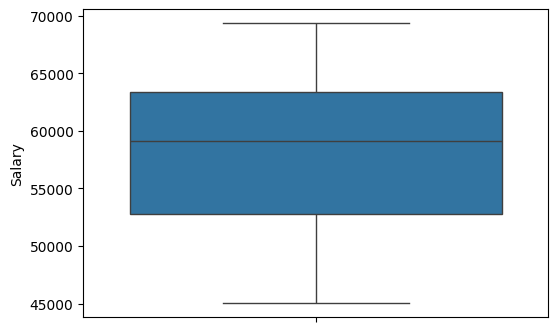

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(sal_range['Salary'])
plt.show()

<Axes: >

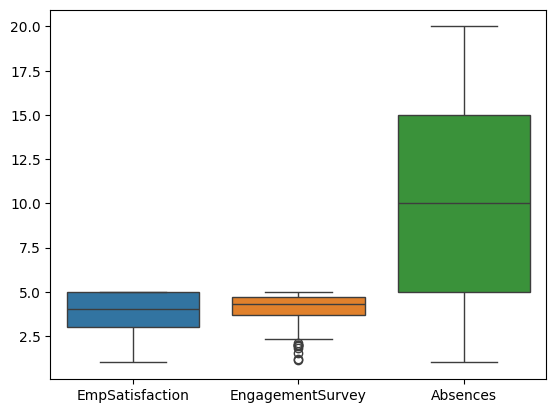

In [19]:
sns.boxplot(hr[['EmpSatisfaction', 'EngagementSurvey', 'Absences']])

## Pie Chart and Donut Chart

In [20]:
ps_pct = hr.groupby('PerformanceScore')['EmpID'].count().reset_index()
ps_pct

,PerformanceScore,EmpID
0,Exceeds,37
1,Fully Meets,243
2,Needs Improvement,18
3,PIP,13


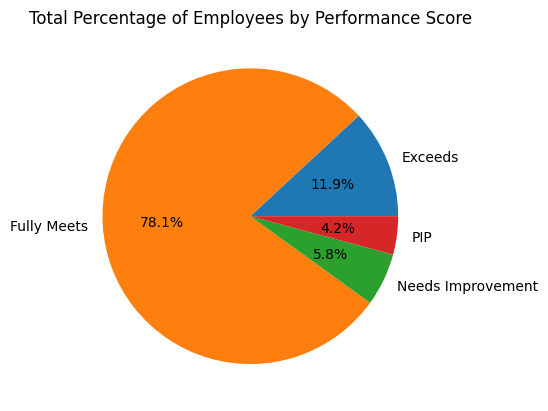

In [21]:
plt.pie(
    ps_pct['EmpID'],
    labels=ps_pct['PerformanceScore'],
    autopct='%1.1f%%'
)
plt.title('Total Percentage of Employees by Performance Score')
plt.show()

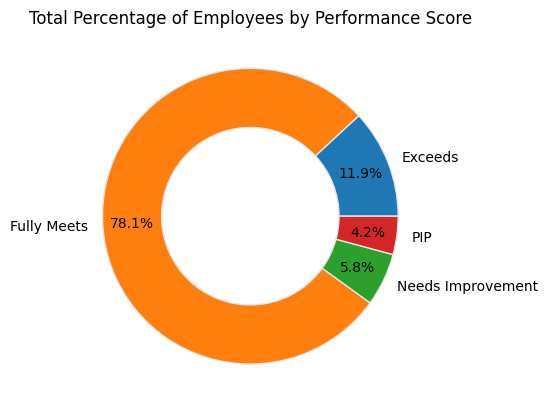

In [22]:
plt.pie(
    ps_pct['EmpID'],
    labels=ps_pct['PerformanceScore'],
    autopct='%1.1f%%',
    # Width Edge Properties
    wedgeprops={'width':0.4, 'edgecolor':'#e5e5e5'},
    pctdistance=0.8
)
plt.title('Total Percentage of Employees by Performance Score')
plt.show()

## Correlation

In [23]:
data = hr.select_dtypes(['int64', 'float64'])

In [24]:
cor_data = data.corr()

<Axes: >

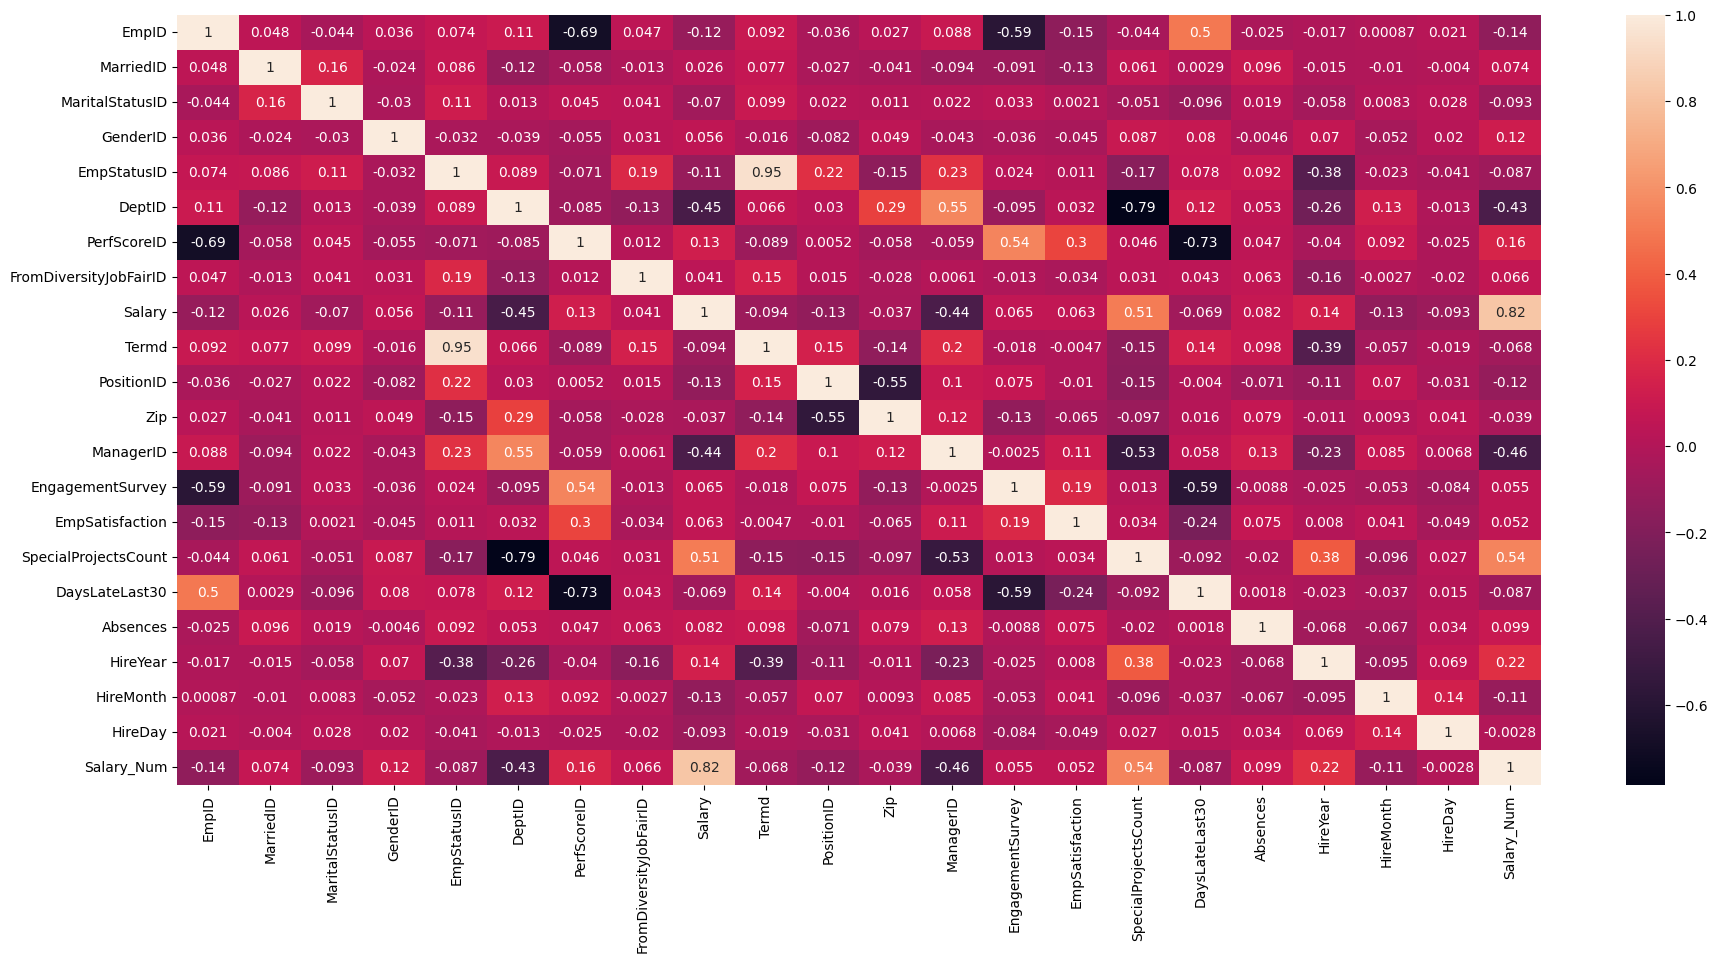

In [25]:
plt.figure(figsize=(22, 10))
sns.heatmap(cor_data, annot=True)

## Column Chart

In [26]:
# Gender, PerformanceScore -> total employees
gender_ps = hr.groupby(['Gender', 'PerformanceScore'])['EmpID'].count().reset_index()
gender_ps

,Gender,PerformanceScore,EmpID
0,F,Exceeds,20
1,F,Fully Meets,142
2,F,Needs Improvement,9
3,F,PIP,5
4,M,Exceeds,17
5,M,Fully Meets,101
6,M,Needs Improvement,9
7,M,PIP,8


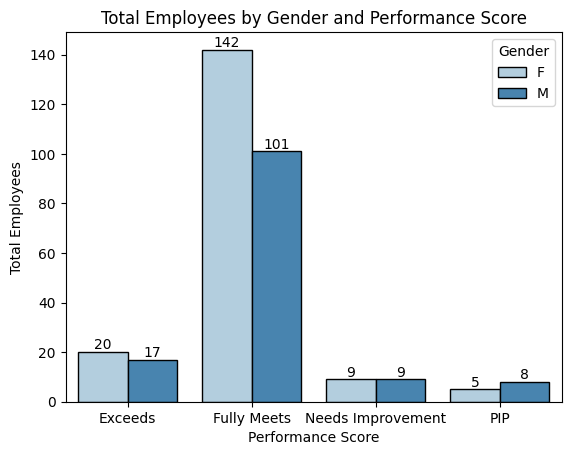

In [27]:
ax = sns.barplot(data=gender_ps, x='PerformanceScore', y='EmpID', hue='Gender', edgecolor='black', errorbar=None,
                palette='Blues')
plt.xlabel('Performance Score')
plt.ylabel('Total Employees')
plt.title('Total Employees by Gender and Performance Score')
for container in ax.containers:
    plt.bar_label(container)
plt.show()

## Sub-Plots

In [28]:
dep_detail = hr.groupby('Department').agg(
    Total_Employees = ('EmpID', 'count'),
    Total_Salary = ('Salary', 'sum'),
    Total_Late_Days = ('DaysLateLast30', 'sum'),
    Total_Absences = ('Absences', 'sum')
).reset_index()
dep_detail

,Department,Total_Employees,Total_Salary,Total_Late_Days,Total_Absences
0,Admin Offices,9,646127,0,78
1,Executive Office,1,250000,0,10
2,IT/IS,50,4853232,7,522
3,Production,209,12530291,98,2120
4,Sales,31,2140899,20,358
5,Software Engineering,11,1044884,4,96


In [29]:
def addBarLabel(dataframe, ax, column_name):
    for idx, val in enumerate(dataframe[column_name]):
        ax.text(idx, val, str(val), ha='center', va='bottom')

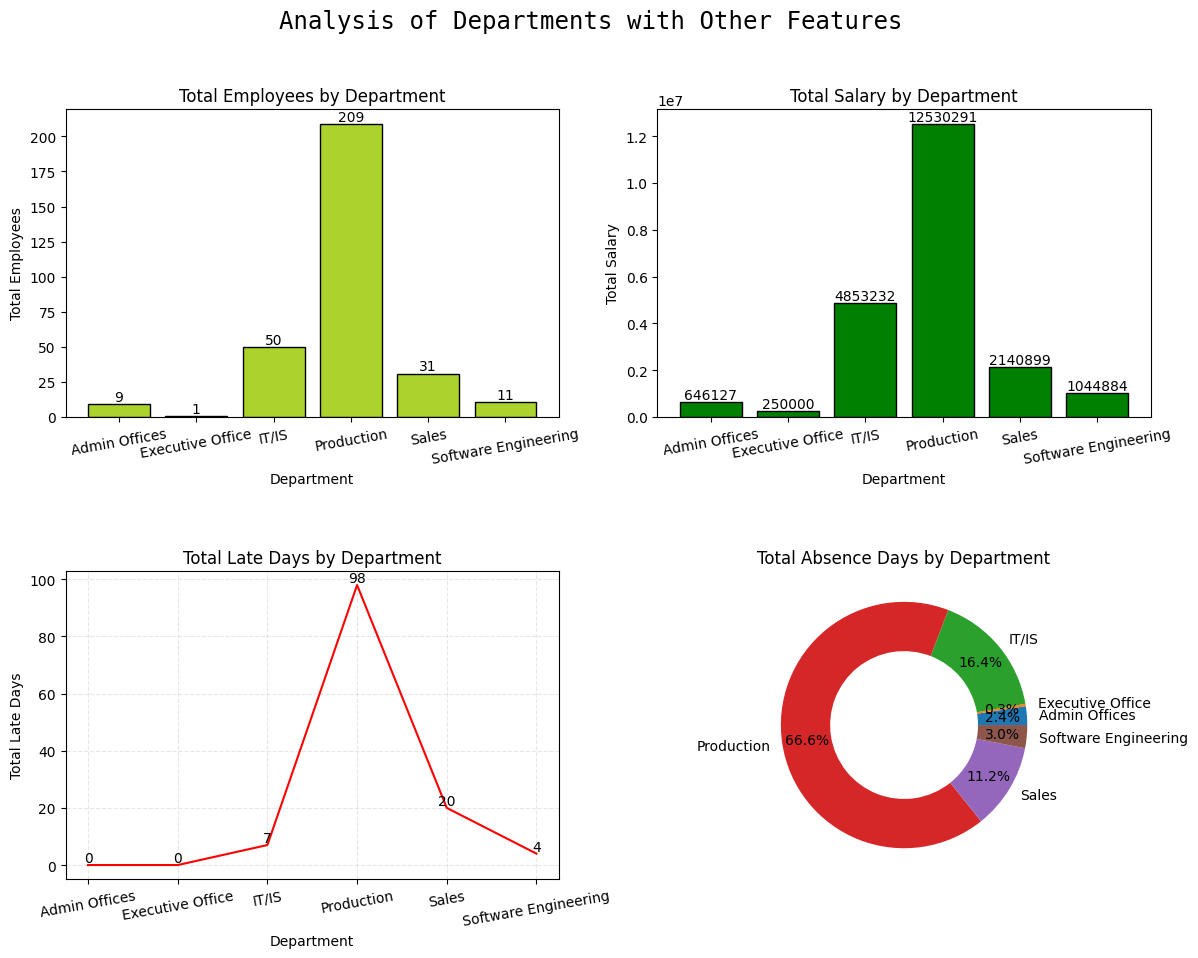

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# wspace=0.5
plt.subplots_adjust(hspace=0.5)
plt.suptitle('Analysis of Departments with Other Features', fontsize='xx-large', fontfamily='monospace')

x_axis = dep_detail['Department']
x_label = 'Department'

ax1 = axes[0, 0]
ax1.bar(x_axis, dep_detail['Total_Employees'], edgecolor='black', color='#acd32b')
ax1.set_xlabel(x_label)
ax1.set_ylabel('Total Employees')
ax1.set_title('Total Employees by Department')
ax1.tick_params(axis='x', rotation=10)
addBarLabel(dep_detail, ax1, 'Total_Employees')


ax2 = axes[0, 1]
ax2.bar(x_axis, dep_detail['Total_Salary'], edgecolor='black', color='green')
ax2.set_xlabel(x_label)
ax2.set_ylabel('Total Salary')
ax2.set_title('Total Salary by Department')
ax2.tick_params(axis='x', rotation=10)
addBarLabel(dep_detail, ax2, 'Total_Salary')

ax3 = axes[1, 0]
ax3.plot(x_axis, dep_detail['Total_Late_Days'], color='red')
ax3.set_xlabel(x_label)
ax3.set_ylabel('Total Late Days')
ax3.set_title('Total Late Days by Department')
ax3.tick_params(axis='x', rotation=10)
ax3.grid(linestyle='dashed', alpha=0.3)
addBarLabel(dep_detail, ax3, 'Total_Late_Days')


ax4 = axes[1, 1]
# ax4.bar(x_axis, dep_detail['Total_Late_Days'])
ax4.pie(
    dep_detail['Total_Absences'],
    labels=x_axis,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4},
    pctdistance=0.8
)
ax4.set_title('Total Absence Days by Department')

plt.savefig('subplot.png')
plt.show()